# 🚴‍♀️ Cyclistic Bike-Share — Report & Results
**Autor:** José Iván garcía  
**Proyecto:** Análisis comparativo de uso entre *miembros anuales* y *ciclistas ocasionales* (May 2022 — Apr 2023)  
**Objetivo:** Identificar diferencias de uso entre *member* y *casual* para proponer campañas de conversión de casual → member.

**Contenido**
- Data snapshot y control de calidad
- Visualizaciones clave (ride length, heatmaps, top stations)
- Pruebas estadísticas (Mann-Whitney, Chi-square)
- Segmentación (KMeans) y recomendaciones operativas
- Objetos: `data/processed/*`, `graphs/*`


## Executive summary
- Analizamos ~5.85M viajes combinados (12 meses) y trabajamos con un dataset limpio y trazable (`data/processed/cyclistic_trips_clean_imputed_v2.snappy.parquet`).
- Hallazgos clave:
  - Proporción: ~60% miembros / ~40% ocasionales en los datos limpios.
  - Los viajes *casual* tienen mediana de duración mayor que *member* (13 vs 9 min) — test Mann-Whitney p<0.001.
  - Patrón horario: *members* concentran viajes en horas punta (comuters), *casuals* muestran picos en fines de semana y turismo.
  - Clusters identificados : 1) commuter (duración corta, hora punta), 2) after-work (tarde), 3) leisure (duraciones largas, fines de semana).
- Recomendaciones:
  - **Commuter Convert**: trials o descuentos para casuals con patrón punta.
  - **Weekend Explorer**: pruebas gratuitas en fines de semana para usuarios con viajes largos.
  - **Station-targeted trials**: campañas geolocalizadas en estaciones con alta densidad de casuals.


## Business question & stakeholders

**Pregunta de negocio:** ¿De qué manera los ciclistas ocasionales y los miembros anuales usan las bicicletas de Cyclistic de manera diferente?  
**Stakeholders:** Directora de Marketing, Equipo de Marketing, Equipo Ejecutivo.  
**Objetivo final:** Generar recomendaciones accionables para convertir casuals a miembros anuales (KPI propuesto: % conversión en 3 meses).


## Objetos utilizados
- `data/processed/first_rows_station_backed.csv` — first rows
- `data/processed/station_backed_sample.csv` — sample
- `data/processed/stat_tests_summary.json` — tests estadísticos (Mann-Whitney, Chi2)
- `data/processed/cluster_centers.csv` — centros de cluster
- `data/processed/audit_validation_summary.csv` — resumen de imputación
- `graphs/*.png` — imágenes

Si quieres reproducir todos los artefactos en local (parquet grandes), consulta `HOW_TO_RUN.md` o los notebooks `01-04`.


In [20]:
# Crear directorios
from pathlib import Path
ROOT = Path('.')
DATA_RAW = ROOT/'data'/'raw'
DATA_PROC = ROOT/'data'/'processed'
GRAPHS = ROOT/'graphs'
for p in [DATA_RAW, DATA_PROC, GRAPHS]:
    p.mkdir(parents=True, exist_ok=True)
print('Ready. Paths:', DATA_RAW, DATA_PROC, GRAPHS)

Ready. Paths: data/raw data/processed graphs


In [21]:
# Comprobación rápida de objetos
from pathlib import Path
DATA_PROC = Path('data/processed')
GRAPHS = Path('graphs')
for p in ['first_rows_station_backed.csv','station_backed_sample.csv','stat_tests_summary.json','cluster_centers.csv','audit_validation_summary.csv']:
    print(p, (DATA_PROC / p).exists())
print("Graphs exist:", any(GRAPHS.glob("*.png")))


first_rows_station_backed.csv True
station_backed_sample.csv True
stat_tests_summary.json True
cluster_centers.csv True
audit_validation_summary.csv True
Graphs exist: False


In [22]:
# Cargar objetos pequeños para presentar
import pandas as pd
from pathlib import Path, PurePosixPath
import json

DATA_PROC = Path('data/processed')
GRAPHS = Path('graphs')

first_rows = pd.read_csv(DATA_PROC / 'first_rows_station_backed.csv')
sample_200 = pd.read_csv(DATA_PROC / 'station_backed_sample.csv')
with open(DATA_PROC / 'stat_tests_summary.json','r') as f:
    stat_tests = json.load(f)
cluster_centers = pd.read_csv(DATA_PROC / 'cluster_centers.csv')
audit_summary = pd.read_csv(DATA_PROC / 'audit_validation_summary.csv')

print("Loaded: first_rows:", first_rows.shape, "sample:", sample_200.shape)
print("stat_tests keys:", list(stat_tests.keys()))
print("cluster centers shape:", cluster_centers.shape)
audit_summary.head(5)


Loaded: first_rows: (10, 24) sample: (200, 54)
stat_tests keys: ['mannwhitney', 'chi2', 'ride_length']
cluster centers shape: (3, 4)


,imputation_method,n_rows,median_nearest_m,pct_within_25m,pct_within_50m,pct_within_100m,pct_ambiguous
0,nearest_100m,498704,3.764,54.079,64.437,100.0,18.87


In [23]:
# Data snapshot: Mostrar las primeras y últimas filas
from IPython.display import display, Markdown
display(Markdown("### Primeras 5 filas (station_backed)"))
display(first_rows.head(5))
display(Markdown("### Muestra aleatoria (200 filas)"))
display(sample_200.head(5))

# Tabla resumida: counts members vs casual
print("Members vs casual (sample):")
display(sample_200['member_casual'].value_counts().to_frame('n'))


### Primeras 5 filas (station_backed)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,ride_length_min,date,hour_of_day,day_of_week,month,is_weekend,coords_start_invalid,coords_end_invalid,distance_km,long_trip_flag
0,EC2DE40644C6B0F4,classic_bike,2022-05-23 23:06:58,2022-05-23 23:40:19,Wabash Ave & Grand Ave,TA1307000117,Halsted St & Roscoe St,TA1309000025,41.891466,-87.626761,...,33.350000,2022-05-23,23,Monday,May,False,False,False,6.088235,False
1,1C31AD03897EE385,classic_bike,2022-05-11 08:53:28,2022-05-11 09:31:22,DuSable Lake Shore Dr & Monroe St,13300,Field Blvd & South Water St,15534,41.880958,-87.616743,...,37.900000,2022-05-11,8,Wednesday,May,False,False,False,0.602870,False
2,1542FBEC830415CF,classic_bike,2022-05-26 18:36:28,2022-05-26 18:58:18,Clinton St & Madison St,TA1305000032,Wood St & Milwaukee Ave,13221,41.882242,-87.641066,...,21.833333,2022-05-26,18,Thursday,May,False,False,False,3.844073,False
3,6FF59852924528F8,classic_bike,2022-05-10 07:30:07,2022-05-10 07:38:49,Clinton St & Madison St,TA1305000032,Clark St & Randolph St,TA1305000030,41.882242,-87.641066,...,8.700000,2022-05-10,7,Tuesday,May,False,False,False,0.802763,False
4,483C52CAAE12E3AC,classic_bike,2022-05-10 17:31:56,2022-05-10 17:36:57,Clinton St & Madison St,TA1305000032,Morgan St & Lake St,TA1306000015,41.882242,-87.641066,...,5.016667,2022-05-10,17,Tuesday,May,False,False,False,0.913438,False


### Muestra aleatoria (200 filas)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,within_50m_end,within_50m_start,within_100m_end,within_100m_start,imputation_method_end,imputation_method_start,imputation_confidence_end,imputation_confidence_start,start_valid_station,end_valid_station
0,91235792BBB61D08,electric_bike,2022-11-25 10:31:24,2022-11-25 10:41:20,Canal St & Adams St,13011,Canal St & Adams St,13011,41.880000,-87.640000,...,True,True,True,True,nearest_100m,nearest_100m,low,low,True,True
1,3C8510CB92BF7248,electric_bike,2023-04-22 17:58:28,2023-04-22 18:01:19,Ellis Ave & 58th St,TA1309000011,Ellis Ave & 55th St,KA1504000076,41.790000,-87.600000,...,True,False,True,True,nearest_100m,nearest_100m,low,low,False,True
2,33C86DBCE8921E0E,electric_bike,2022-05-25 19:14:03,2022-05-25 19:16:54,Ellis Ave & 58th St,TA1309000011,Hyde Park Blvd & 55th St,768,41.790000,-87.600000,...,True,False,True,True,nearest_100m,nearest_100m,low,low,False,True
3,B9F47C37D3B49B57,electric_bike,2022-06-13 18:21:21,2022-06-13 18:21:59,Wilton Ave & Diversey Pkwy,TA1306000014,Halsted St & Wrightwood Ave,TA1309000061,41.932368,-87.652698,...,False,True,True,True,nearest_100m,nearest_100m,low,low,True,False
4,A4DC498B1290FDAF,electric_bike,2022-05-28 13:19:38,2022-05-28 13:24:16,New St & Illinois St,TA1306000013,New St & Illinois St,TA1306000013,41.890000,-87.620000,...,True,True,True,True,nearest_100m,nearest_100m,low,low,True,True


Members vs casual (sample):


,n
member_casual,
member,140
casual,60


## Calidad de datos e imputación (resumen)
Se usaron reglas conservadoras para aceptar filas “station-backed”:
- Aceptadas filas con estación conocida y validación espacial confiable (<=50m & no ambiguo) o **confidence == 'high'**.
- Se mantiene trazabilidad: `imputation_log_v2.csv` e `imputation_validation_rows.csv` en `data/processed/`.

A continuación, resumen del audit:


In [24]:
display(audit_summary)
# mostrar líneas clave
print("Audit summary keys:", list(audit_summary.columns))


,imputation_method,n_rows,median_nearest_m,pct_within_25m,pct_within_50m,pct_within_100m,pct_ambiguous
0,nearest_100m,498704,3.764,54.079,64.437,100.0,18.87


Audit summary keys: ['imputation_method', 'n_rows', 'median_nearest_m', 'pct_within_25m', 'pct_within_50m', 'pct_within_100m', 'pct_ambiguous']


## Análisis exploratorio de datos (EDA visual)

### Trips by member type

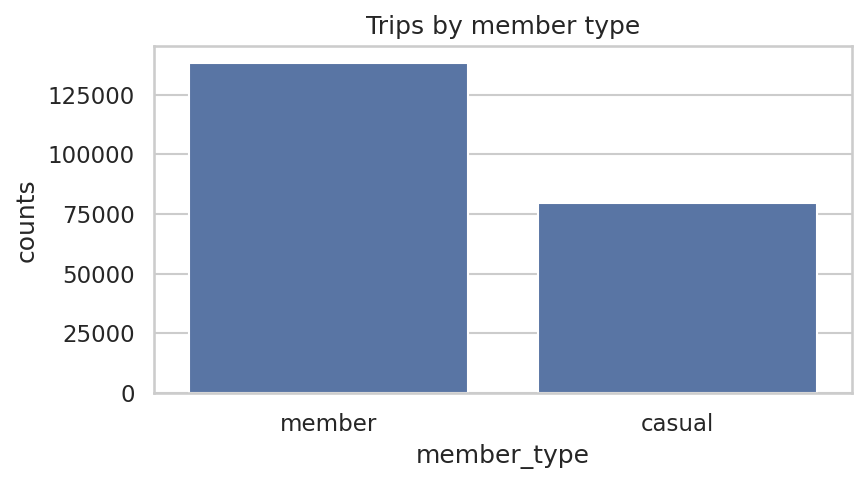

### Ride length distribution (log y)

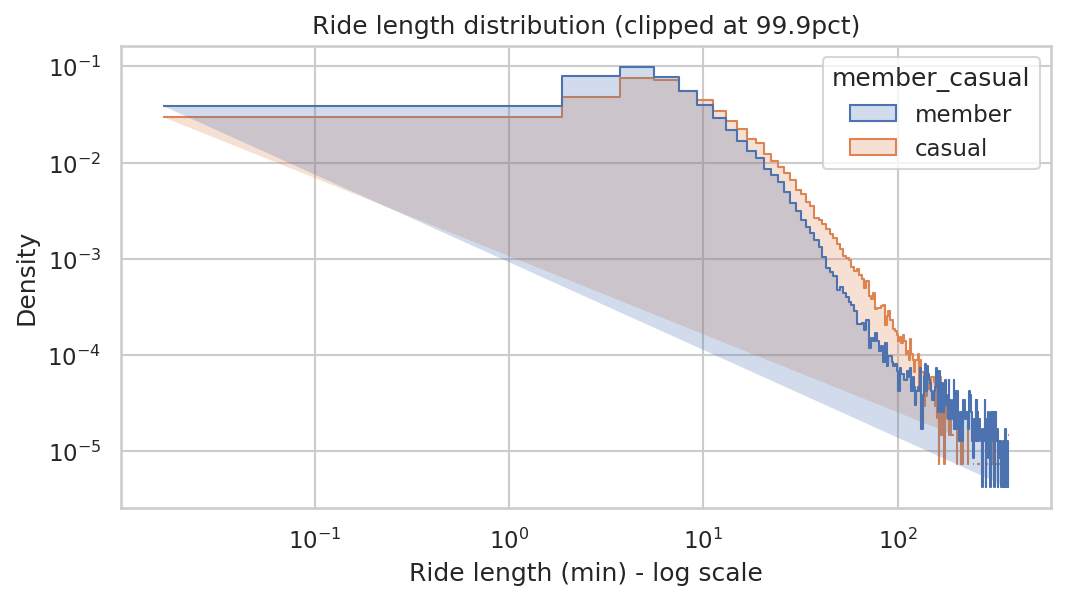

### Heatmap: Members (day x hour)

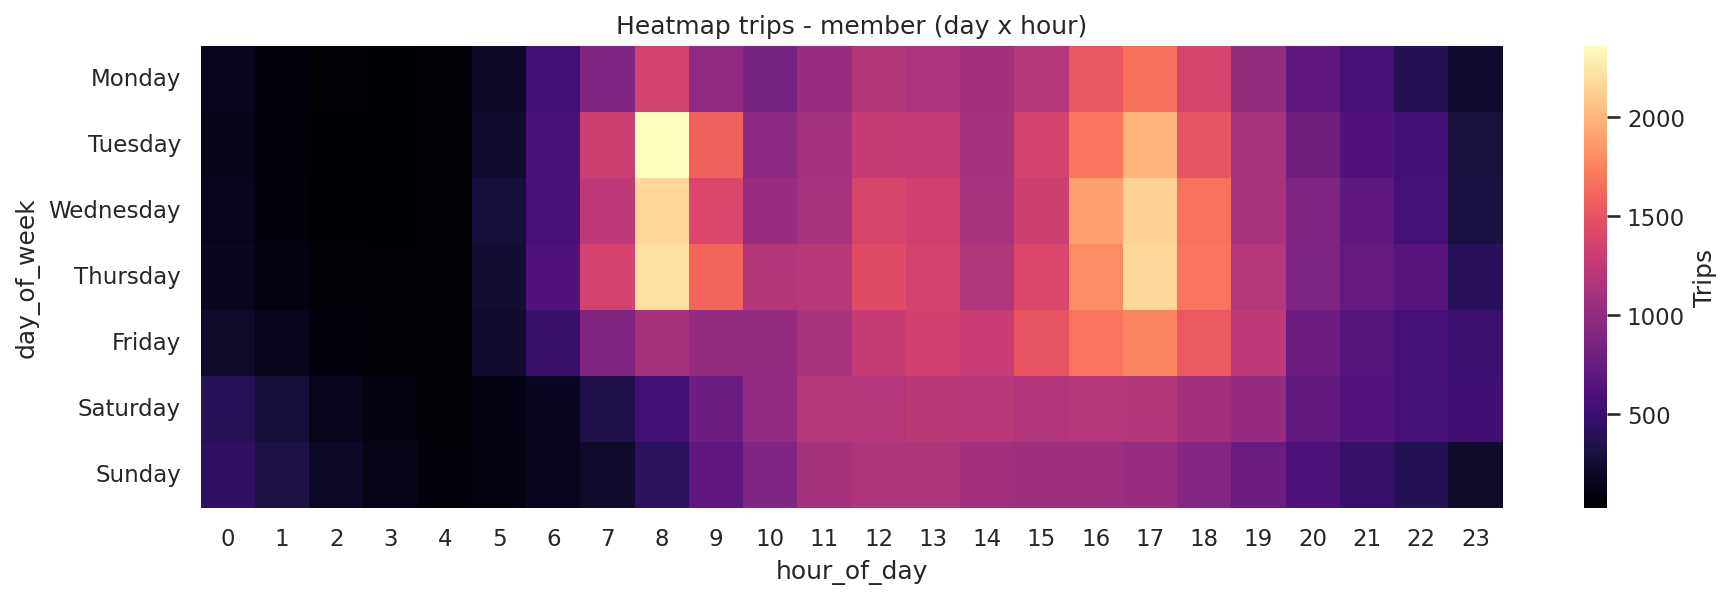

### Heatmap: Casuals (day x hour)

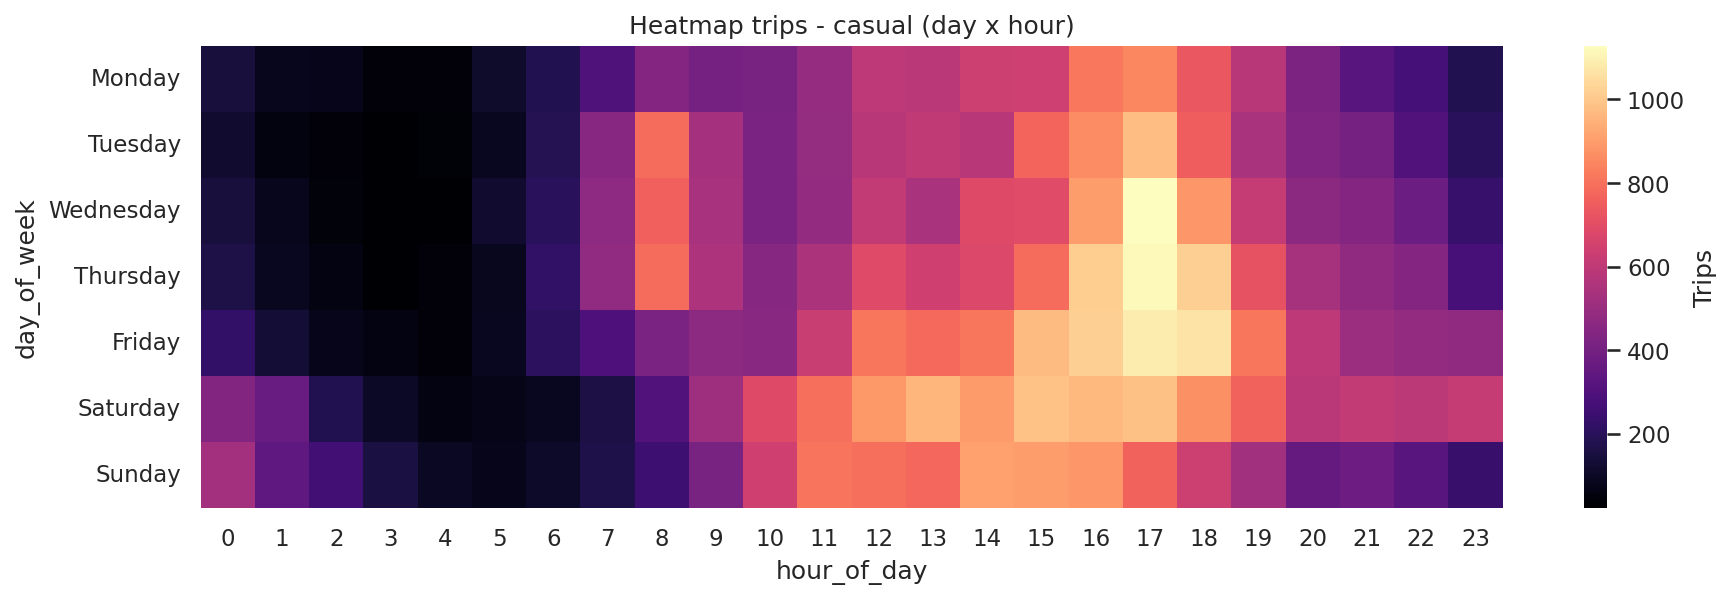

### Top start stations — Members

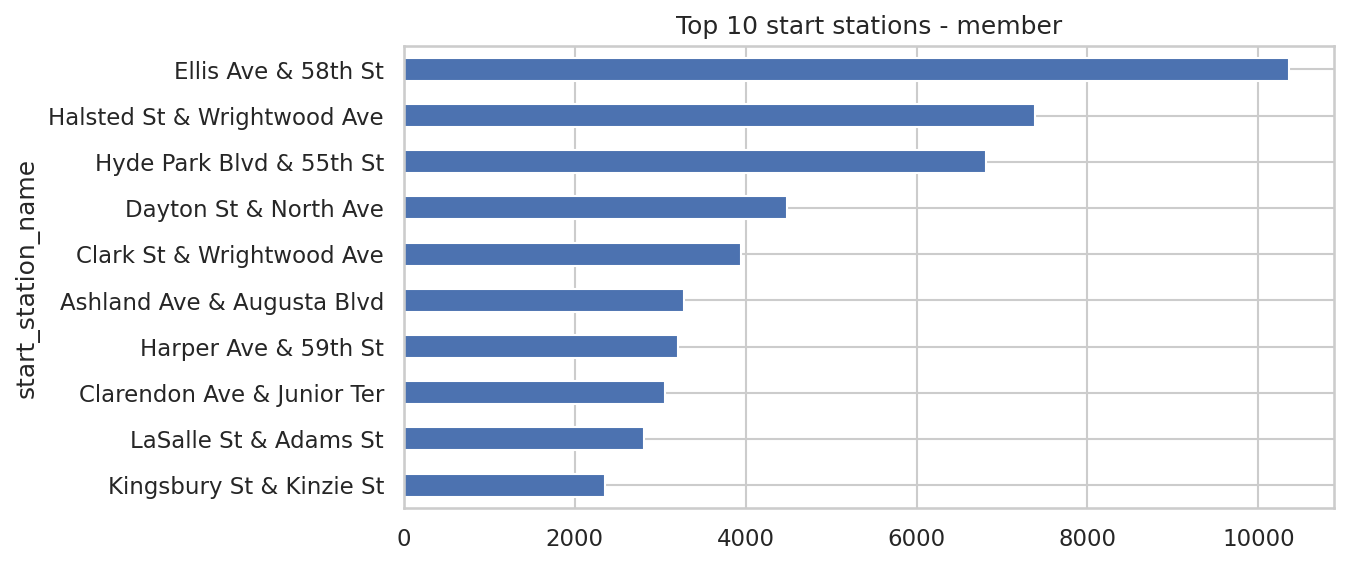

### Top start stations — Casuals

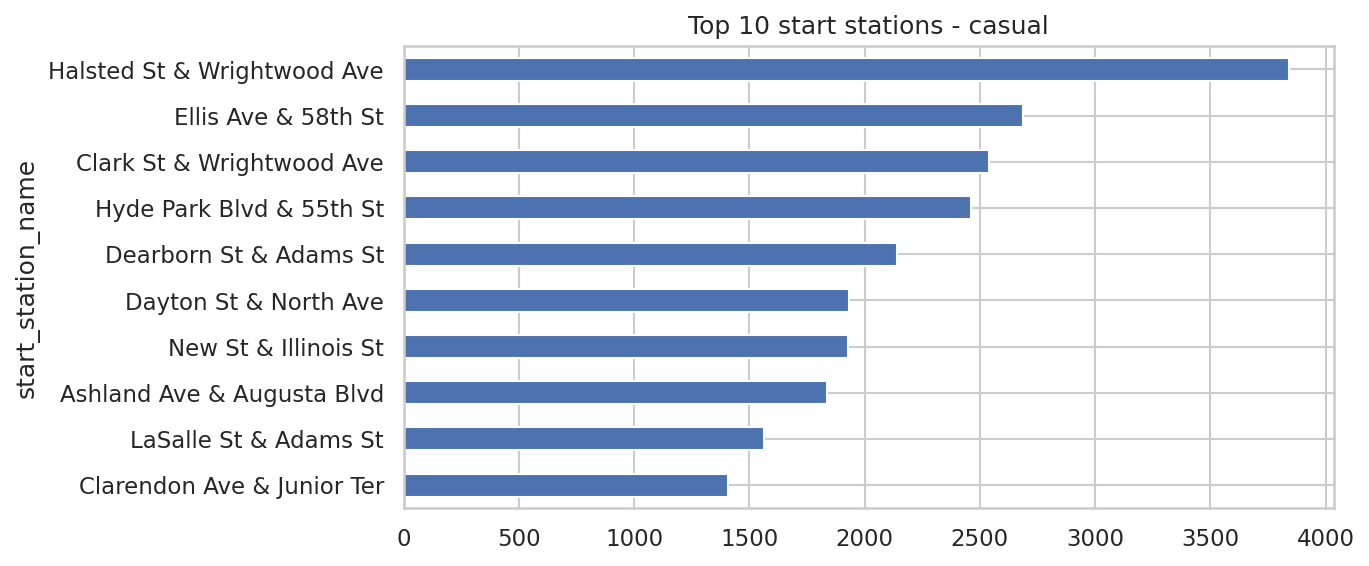

In [6]:
from IPython.display import Image, display, Markdown

display(Markdown("### Trips by member type"))
display(Image(filename=str(GRAPHS / 'trips_by_member_type.png')))
display(Markdown("### Ride length distribution (log y)"))
display(Image(filename=str(GRAPHS / 'dist_ride_length_logy.png')))
display(Markdown("### Heatmap: Members (day x hour)"))
display(Image(filename=str(GRAPHS / 'heatmap_day_hour_member.png')))
display(Markdown("### Heatmap: Casuals (day x hour)"))
display(Image(filename=str(GRAPHS / 'heatmap_day_hour_casual.png')))
display(Markdown("### Top start stations — Members"))
display(Image(filename=str(GRAPHS / 'top10_start_member.png')))
display(Markdown("### Top start stations — Casuals"))
display(Image(filename=str(GRAPHS / 'top10_start_casual.png')))


## Tests estadísticos

In [26]:
# Stat tests loaded earlier in stat_tests
# Si stat_tests fue guardado con estructura {'mann_whitney': {...}, 'chi2': {...}}
import json
from IPython.display import Markdown, display

print("Keys in stat_tests:", list(stat_tests.keys()))

# mann-whitney
if 'mannwhitney' in stat_tests:
    mw = stat_tests['mannwhitney']
    display(Markdown(f"**Mann-Whitney U**: statistic={mw.get('stat', mw.get('U','n/a'))}, p={mw.get('p', 'n/a')}"))
    #display(Markdown(f"**Median (member)**: {mw.get('median_member','n/a')} min"))
    #display(Markdown(f"**Median (casual)**: {mw.get('median_casual','n/a')} min"))
else:
    display(Markdown("Mann-Whitney results not found in stat_tests_summary.json"))

# Chi-square
if 'chi2' in stat_tests:
    chi = stat_tests['chi2']
    display(Markdown(f"**Chi2**: chi2={chi.get('chi2')}, p={chi.get('p')}, dof={chi.get('dof')}"))
else:
    display(Markdown("Chi-square results not found"))

# ride_length
if 'ride_length' in stat_tests:
    rl = stat_tests['ride_length']
    display(Markdown(f"**Median (member)**: {rl.get('median_member','n/a')} min"))
    display(Markdown(f"**Median (casual)**: {rl.get('median_casual','n/a')} min"))
    display(Markdown(f"**Median_diff**: {rl.get('median_diff','n/a')} min"))
else:
    display(Markdown("ride_length results not found in stat_tests_summary.json"))



Keys in stat_tests: ['mannwhitney', 'chi2', 'ride_length']


**Mann-Whitney U**: statistic=3290524717.0, p=0.0

**Chi2**: chi2=0.114558698141894, p=0.735012640300694, dof=1

**Median (member)**: 6.766666666666667 min

**Median (casual)**: 8.816666666666666 min

**Median_diff**: -2.05 min

In [28]:
display(Markdown("### Centros de cluster (features: ride_length_min, hour_of_day, distance_km)"))
display(cluster_centers)

# Interpretación
display(Markdown("""
**Interpretación rápida de clusters :**
- Cluster 0: viajes y distancia cortos (7.8 min) y (1.4 km), periodos pico de tarde/noche (17.6) - objetivo *promociones after-work*.
- Cluster 1: viajes largos (30.1 min) y distancia mayor (5.1 km), hora promedio alrededor del mediodía/tarde (13.9), probablemente **viajes de ocio o turísticos**  — objetivo: *Weekend Explorer* trials.
- Cluster 2: viajes y distancia cortos (7.5 min) y (1.4 km), hora promedio de viaje en la mañana (9.0)  — objetivo: *Commuter Convert*.
"""))


### Centros de cluster (features: ride_length_min, hour_of_day, distance_km)

,cluster,ride_length_min,hour_of_day,distance_km
0,0,7.802354,17.623107,1.366283
1,1,30.133892,13.983171,5.163853
2,2,7.481122,9.087769,1.396748



**Interpretación rápida de clusters :**
- Cluster 0: viajes y distancia cortos (7.8 min) y (1.4 km), periodos pico de tarde/noche (17.6) - objetivo *promociones after-work*.
- Cluster 1: viajes largos (30.1 min) y distancia mayor (5.1 km), hora promedio alrededor del mediodía/tarde (13.9), probablemente **viajes de ocio o turísticos**  — objetivo: *Weekend Explorer* trials.
- Cluster 2: viajes y distancia cortos (7.5 min) y (1.4 km), hora promedio de viaje en la mañana (9.0)  — objetivo: *Commuter Convert*.


## Recomendaciones operativas (resumen accionable)

1. **Commuter Convert**  
   - Segmento objetivo: usuarios ocasionales con viajes en hora punta (ver heatmap + cluster center ≈ hora 7–9 y 17–19, duración corta).  
   - Oferta: prueba de membresía trimestral con descuento + recordatorios push en horario de la mañana/ tarde.  
   - KPI: % conversión casual→member en 3 meses; objetivo inicial 3–5%.

2. **Weekend Explorer**  
   - Segmento objetivo: ocasionales con alta duración y picos de fines de semana (ver cluster leisure y heatmap fines de semana).  
   - Oferta: trial de membresía fin de semana (2 fines de semana gratis) o cupones para eventos locales.  
   - KPI: número de trials activados por mes; conversión 4–6% post-trial.

3. **Station-targeted Trials**  
   - Identificar top estaciones con concentración alta de casuals (ver `top10_start_casual.png`) y deploy de campañas físicas/QR-codes que ofrezcan trials.  
   - KPI: CTR del QR / % de usuarios de esa estación que se registran como miembro.

**Medición y seguimiento:**  
- Configurar cohortes semanales y comparar % conversión en cohortes expuestas vs no expuestas.  
- Reporte mensual: #trials, #conversions, ARPU por segmento.


## Limitaciones y próximos pasos

**Limitaciones**
- No contamos con variables personales (edad, ingreso, residencia) por restricción de privacidad; análisis limitado a preferencias reveladas por comportamiento.
- Algunas imputaciones siguen sin nombre/id de estación (se usó criterio conservador). Ver `imputation_log_v2.csv` para trazabilidad.
- El clustering es exploratorio; se recomienda validar con datos A/B y métricas de conversión reales antes de desplegar campañas.

**Próximos pasos**
- Implementar experimento A/B para Commuter Convert y medir resultado en 3 meses.
- Integración con tracking digital para atribución de campaña (UTM + QR).
- Refinar el modelo de imputación usando fuentes externas de estaciones (API) y mejorar map-matching.


In [33]:
# Generar results_summary.md basado en lo mostrado
from pathlib import Path
import json
DATA_PROC = Path('data/processed')
OUT = Path('results_summary.md')

summary_lines = []
summary_lines.append("# Results summary — Cyclistic Bike-Share\n")
summary_lines.append("**Rows analyzed (station_backed sample):** See `data/processed/station_backed_counts.csv`\n")
summary_lines.append("## Key findings\n")
# add a compact summary using stat_tests if present
if 'mannwhitney' in stat_tests:
    mw = stat_tests['mannwhitney']
    summary_lines.append(f"- Mann-Whitney - statistic={mw.get('stat', mw.get('U','n/a'))}.p={mw.get('p','n/a')}\n")

if 'ride_length' in stat_tests:
    mw = stat_tests['ride_length']
    summary_lines.append(f"- Ride length median (member): {mw.get('median_member','n/a')} min; (casual): {mw.get('median_casual','n/a')} min.\n")

if 'chi2' in stat_tests:
    chi = stat_tests['chi2']
    summary_lines.append(f"- Association rideable_type vs member_casual: chi2={chi.get('chi2')}, p={chi.get('p')}\n")
summary_lines.append("\n## Visuals\n")
for im in ['trips_by_member_type.png','dist_ride_length_logy.png','heatmap_day_hour_member.png','heatmap_day_hour_casual.png','top10_start_member.png','top10_start_casual.png']:
    summary_lines.append(f"- graphs/{im}\n")
summary_lines.append("\n## Recommendations (short)\n")
summary_lines.append("- Commuter Convert: trials/discounts para casuals en hora punta.\n")
summary_lines.append("- Weekend Explorer: trials para viajeros de fin de semana.\n")
summary_lines.append("- Station-targeted trials: campañas geolocalizadas en top casual stations.\n")
OUT.write_text("\n".join(summary_lines), encoding='utf-8')
print("Wrote", OUT)


Wrote results_summary.md
